# Day 41
- Lgostic Regression

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

In [17]:
print(sigmoid(-5))  

0.0066928509242848554


In [25]:
def generate_dataset():
    dataset = make_classification(
        n_samples=30, n_features=1, n_repeated=0, n_redundant=0, 
        shift=30, scale=10, class_sep=1, random_state=1, 
        n_clusters_per_class=1, n_informative=1, n_classes=2
    )
    df = pd.DataFrame(dataset[0])
    df = pd.concat([(np.ceil(df)).astype(int), pd.DataFrame(dataset[1])], axis=1)
    
    df.columns = ['GRE_Score', 'Admission']
    
    return df

data = generate_dataset()


In [26]:
data.head()

,GRE_Score,Admission
0,287,0
1,295,0
2,317,1
3,300,0
4,310,1


<Axes: xlabel='GRE_Score', ylabel='Admission'>

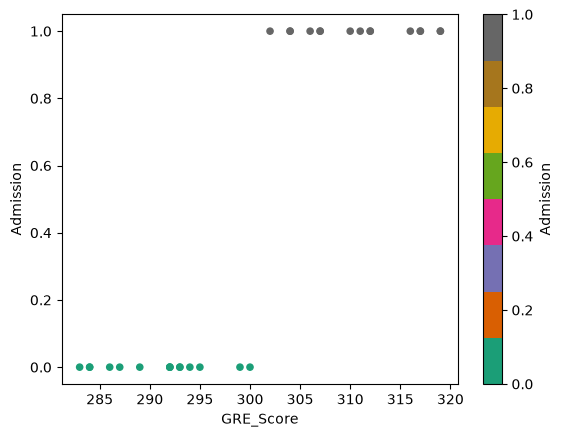

In [28]:
data.plot.scatter(x='GRE_Score', y='Admission', c='Admission',cmap = "Dark2")

In [29]:
from sklearn.linear_model import LinearRegression

In [30]:
map_color = np.array(['r','b'])
x = data[['GRE_Score']].to_numpy()
y=data[["Admission"]].to_numpy()

In [31]:
linear_reg = LinearRegression()
linear_reg.fit(x,y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1, 1)",[[0.04]]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.","ndarray[float64](1,)",[-11.22]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[62.06]


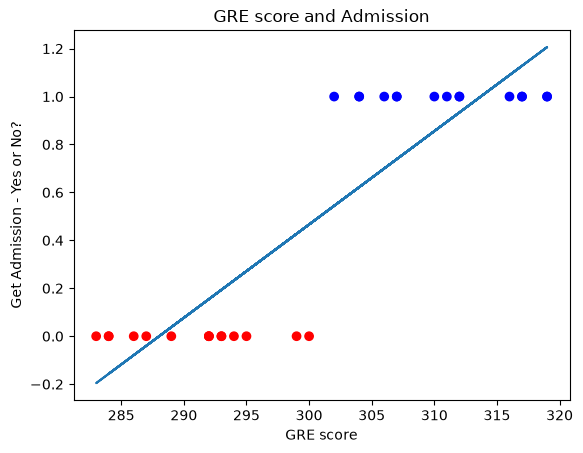

In [32]:
plt.scatter(x, y, c=map_color[y.ravel()])
plt.plot(x, linear_reg.predict(x))
plt.title("GRE score and Admission")
plt.xlabel("GRE score")
plt.ylabel("Get Admission - Yes or No?")
plt.show()

In [33]:
y_hat = linear_reg.predict(x)


In [34]:
y_hat

array([[-0.04005401],
       [ 0.27151561],
       [ 1.12833206],
       [ 0.46624662],
       [ 0.85570865],
       [ 0.0378384 ],
       [ 0.15467701],
       [ 0.42730042],
       [-0.07900021],
       [ 0.54413903],
       [-0.19583881],
       [ 0.73887004],
       [ 0.93360105],
       [ 0.89465485],
       [ 1.20622447],
       [ 0.62203143],
       [ 0.19362321],
       [ 0.69992384],
       [ 0.15467701],
       [ 0.19362321],
       [ 0.15467701],
       [-0.15689261],
       [ 1.20622447],
       [-0.15689261],
       [ 0.62203143],
       [ 1.08938586],
       [ 0.23256941],
       [ 1.12833206],
       [ 0.93360105],
       [ 0.73887004]])

In [35]:
prob_y = sigmoid(y_hat)

In [36]:
prob_y

array([[0.48998784],
       [0.56746495],
       [0.75553096],
       [0.614495  ],
       [0.70176329],
       [0.50945847],
       [0.53859234],
       [0.60522885],
       [0.48026021],
       [0.63277474],
       [0.45119618],
       [0.67674872],
       [0.71780529],
       [0.70984984],
       [0.76963023],
       [0.65068043],
       [0.54825514],
       [0.66817089],
       [0.53859234],
       [0.54825514],
       [0.53859234],
       [0.46085711],
       [0.76963023],
       [0.46085711],
       [0.65068043],
       [0.74826606],
       [0.55788169],
       [0.75553096],
       [0.71780529],
       [0.67674872]])

In [39]:
threshold = 0.6

result = (prob_y > threshold)
result.astype(int)

array([[0],
       [0],
       [1],
       [1],
       [1],
       [0],
       [0],
       [1],
       [0],
       [1],
       [0],
       [1],
       [1],
       [1],
       [1],
       [1],
       [0],
       [1],
       [0],
       [0],
       [0],
       [0],
       [1],
       [0],
       [1],
       [1],
       [0],
       [1],
       [1],
       [1]])